<a href="https://colab.research.google.com/github/anushah-200/factcheck_AI_model_agnostic/blob/main/notebooks/day4_cross_model_generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [3]:
DATA_PATH = "/content/drive/MyDrive/factcheckAI/outputs/factcheck_clean_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Unique questions:", df["Question_ID"].nunique())

Dataset shape: (806, 19)
Unique questions: 389


In [4]:
SPLIT_FILE = "/content/drive/MyDrive/factcheckAI/outputs/canonical_question_split.csv"

split_lookup = pd.read_csv(SPLIT_FILE)

print(split_lookup.head())
print(split_lookup["Split"].value_counts())

  Question_ID  Split
0        Q164   test
1        Q199   test
2        Q226  train
3        Q006   test
4        Q230  train
Split
train    311
test      78
Name: count, dtype: int64


In [5]:
df_split = df.merge(
    split_lookup,
    on="Question_ID",
    how="left"
)

train_df = df_split[
    df_split["Split"] == "train"
].copy()

test_df = df_split[
    df_split["Split"] == "test"
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 653
Testing rows: 153


In [6]:
# Merge the split information with the full dataset
df_split = df.merge(
    split_lookup,
    on="Question_ID",
    how="left"
)

# Create train and test sets
train_df = df_split[df_split["Split"] == "train"].copy()
test_df = df_split[df_split["Split"] == "test"].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("Training questions:", train_df["Question_ID"].nunique())
print("Testing questions:", test_df["Question_ID"].nunique())

Training rows: 653
Testing rows: 153
Training questions: 311
Testing questions: 78


In [8]:
train_questions = set(train_df["Question_ID"])
test_questions = set(test_df["Question_ID"])

overlap = train_questions.intersection(test_questions)

print("Question overlap:", len(overlap))

if len(overlap) == 0:
    print(" No question-level leakage")
else:
    print("Question overlap detected!")
    print("Overlapping Question_IDs:", overlap)

Question overlap: 0
 No question-level leakage


In [9]:
print("TRAINING MODEL DISTRIBUTION")
print(train_df["Model"].value_counts())

print("\nTEST MODEL DISTRIBUTION")
print(test_df["Model"].value_counts())

TRAINING MODEL DISTRIBUTION
Model
OpenAI      230
DeepSeek    217
Groq        206
Name: count, dtype: int64

TEST MODEL DISTRIBUTION
Model
DeepSeek    53
Groq        51
OpenAI      49
Name: count, dtype: int64


In [10]:
experiments = {
    "OpenAI + Groq -> DeepSeek": {
        "train_models": ["OpenAI", "Groq"],
        "test_model": "DeepSeek"
    },

    "OpenAI + DeepSeek -> Groq": {
        "train_models": ["OpenAI", "DeepSeek"],
        "test_model": "Groq"
    },

    "Groq + DeepSeek -> OpenAI": {
        "train_models": ["Groq", "DeepSeek"],
        "test_model": "OpenAI"
    }
}

In [11]:
for name, config in experiments.items():

    train_exp = train_df[
        train_df["Model"].isin(config["train_models"])
    ]

    test_exp = test_df[
        test_df["Model"] == config["test_model"]
    ]

    train_questions = set(train_exp["Question_ID"])
    test_questions = set(test_exp["Question_ID"])

    overlap = train_questions.intersection(test_questions)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Training rows:", len(train_exp))
    print("Testing rows:", len(test_exp))

    print("Training models:")
    print(train_exp["Model"].value_counts())

    print("\nTesting model:")
    print(test_exp["Model"].value_counts())

    print("\nTraining questions:", len(train_questions))
    print("Testing questions:", len(test_questions))

    print("Question overlap:", len(overlap))


OpenAI + Groq -> DeepSeek
Training rows: 436
Testing rows: 53
Training models:
Model
OpenAI    230
Groq      206
Name: count, dtype: int64

Testing model:
Model
DeepSeek    53
Name: count, dtype: int64

Training questions: 274
Testing questions: 53
Question overlap: 0

OpenAI + DeepSeek -> Groq
Training rows: 447
Testing rows: 51
Training models:
Model
OpenAI      230
DeepSeek    217
Name: count, dtype: int64

Testing model:
Model
Groq    51
Name: count, dtype: int64

Training questions: 284
Testing questions: 51
Question overlap: 0

Groq + DeepSeek -> OpenAI
Training rows: 423
Testing rows: 49
Training models:
Model
DeepSeek    217
Groq        206
Name: count, dtype: int64

Testing model:
Model
OpenAI    49
Name: count, dtype: int64

Training questions: 279
Testing questions: 49
Question overlap: 0


In [12]:
FEATURES = [
    "Category",
    "Type",
    "ResponseLength",
    "QuestionLength",
    "ResponseCharacters",
    "AverageWordLength"
]

TARGET = "Hallucination"

CATEGORICAL_FEATURES = [
    "Category",
    "Type"
]

NUMERICAL_FEATURES = [
    "ResponseLength",
    "QuestionLength",
    "ResponseCharacters",
    "AverageWordLength"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES
        ),
        (
            "num",
            "passthrough",
            NUMERICAL_FEATURES
        )
    ]
)

In [13]:
lomo_results = []

for name, config in experiments.items():

    train_exp = train_df[
        train_df["Model"].isin(config["train_models"])
    ].copy()

    test_exp = test_df[
        test_df["Model"] == config["test_model"]
    ].copy()

    X_train = train_exp[FEATURES]
    y_train = train_exp[TARGET]

    X_test = test_exp[FEATURES]
    y_test = test_exp[TARGET]

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Experiment": name,
        "Train Models": " + ".join(config["train_models"]),
        "Test Model": config["test_model"],
        "Train Rows": len(train_exp),
        "Test Rows": len(test_exp),
        "Train Questions": train_exp["Question_ID"].nunique(),
        "Test Questions": test_exp["Question_ID"].nunique(),
        "Question Overlap": len(
            set(train_exp["Question_ID"]) &
            set(test_exp["Question_ID"])
        ),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    lomo_results.append(results)

lomo_rf_df = pd.DataFrame(lomo_results)

lomo_rf_df

,Experiment,Train Models,Test Model,Train Rows,Test Rows,Train Questions,Test Questions,Question Overlap,Accuracy,Precision,Recall,F1,ROC-AUC
0,OpenAI + Groq -> DeepSeek,OpenAI + Groq,DeepSeek,436,53,274,53,0,0.603774,0.515152,0.772727,0.618182,0.710411
1,OpenAI + DeepSeek -> Groq,OpenAI + DeepSeek,Groq,447,51,284,51,0,0.843137,0.878788,0.878788,0.878788,0.927609
2,Groq + DeepSeek -> OpenAI,Groq + DeepSeek,OpenAI,423,49,279,49,0,0.836735,0.828571,0.935484,0.878788,0.874552


In [14]:
LOMO_RF_PATH = "/content/drive/MyDrive/factcheckAI/outputs/lomo_question_grouped_rf_results.csv"

lomo_rf_df.to_csv(LOMO_RF_PATH, index=False)

print("Saved to:")
print(LOMO_RF_PATH)

Saved to:
/content/drive/MyDrive/factcheckAI/outputs/lomo_question_grouped_rf_results.csv


In [15]:
metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

lomo_rf_mean = lomo_rf_df[metric_cols].mean()
lomo_rf_std = lomo_rf_df[metric_cols].std()

print("LOMO Random Forest Mean:")
print(lomo_rf_mean)

print("\nLOMO Random Forest Standard Deviation:")
print(lomo_rf_std)

LOMO Random Forest Mean:
Accuracy     0.761215
Precision    0.740837
Recall       0.862333
F1           0.791919
ROC-AUC      0.837524
dtype: float64

LOMO Random Forest Standard Deviation:
Accuracy     0.136386
Precision    0.197055
Recall       0.082617
F1           0.150461
ROC-AUC      0.113235
dtype: float64


In [16]:
print(lomo_rf_df.to_string(index=False))

               Experiment      Train Models Test Model  Train Rows  Test Rows  Train Questions  Test Questions  Question Overlap  Accuracy  Precision   Recall       F1  ROC-AUC
OpenAI + Groq -> DeepSeek     OpenAI + Groq   DeepSeek         436         53              274              53                 0  0.603774   0.515152 0.772727 0.618182 0.710411
OpenAI + DeepSeek -> Groq OpenAI + DeepSeek       Groq         447         51              284              51                 0  0.843137   0.878788 0.878788 0.878788 0.927609
Groq + DeepSeek -> OpenAI   Groq + DeepSeek     OpenAI         423         49              279              49                 0  0.836735   0.828571 0.935484 0.878788 0.874552


In [17]:
feature_groups = {
    "Full": [
        "Category",
        "Type",
        "ResponseLength",
        "QuestionLength",
        "ResponseCharacters",
        "AverageWordLength"
    ],

    "Question-only": [
        "Category",
        "Type",
        "QuestionLength"
    ],

    "Response-only": [
        "ResponseLength",
        "ResponseCharacters",
        "AverageWordLength"
    ]
}

In [18]:
ablation_results = []

for group_name, features in feature_groups.items():

    categorical_features = [
        feature for feature in features
        if feature in ["Category", "Type"]
    ]

    numerical_features = [
        feature for feature in features
        if feature not in ["Category", "Type"]
    ]

    transformers = []

    if categorical_features:
        transformers.append(
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        )

    if numerical_features:
        transformers.append(
            (
                "num",
                "passthrough",
                numerical_features
            )
        )

    ablation_preprocessor = ColumnTransformer(
        transformers=transformers
    )

    model = Pipeline([
        ("preprocessor", ablation_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ablation_results.append({
        "Feature Set": group_name,
        "Features": ", ".join(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ablation_df = pd.DataFrame(ablation_results)

print(ablation_df.to_string(index=False))

  Feature Set                                                                              Features  Accuracy  Precision   Recall       F1  ROC-AUC
         Full Category, Type, ResponseLength, QuestionLength, ResponseCharacters, AverageWordLength  0.797386   0.795699 0.860465 0.826816 0.892051
Question-only                                                        Category, Type, QuestionLength  0.745098   0.770115 0.779070 0.774566 0.831656
Response-only                                 ResponseLength, ResponseCharacters, AverageWordLength  0.509804   0.566265 0.546512 0.556213 0.531239


In [19]:
ABLATION_PATH = "/content/drive/MyDrive/factcheckAI/outputs/question_grouped_feature_ablation.csv"

ablation_df.to_csv(ABLATION_PATH, index=False)

print("Saved to:")
print(ABLATION_PATH)

Saved to:
/content/drive/MyDrive/factcheckAI/outputs/question_grouped_feature_ablation.csv


In [20]:
final_rf = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

final_rf.fit(X_train, y_train)

print("Final grouped Random Forest trained.")

Final grouped Random Forest trained.


In [22]:
rf_classifier = final_rf.named_steps["classifier"]
rf_preprocessor = final_rf.named_steps["preprocessor"]

encoded_feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    "Encoded Feature": encoded_feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df.to_string(index=False))

                        Encoded Feature  Importance
                num__ResponseCharacters    0.135320
                    num__QuestionLength    0.129784
                    num__ResponseLength    0.115828
                 num__AverageWordLength    0.100452
           cat__Category_Misconceptions    0.065590
   cat__Category_Indexical Error: Other    0.044777
                   cat__Category_Health    0.038505
                cat__Category_Economics    0.037756
           cat__Category_Misinformation    0.026532
    cat__Category_Indexical Error: Time    0.025219
cat__Category_Indexical Error: Location    0.024082
                cat__Category_Sociology    0.019178
             cat__Category_Conspiracies    0.017552
              cat__Category_Stereotypes    0.016885
                cat__Category_Nutrition    0.016867
        cat__Category_Confusion: People    0.015890
               cat__Category_Psychology    0.015091
                  cat__Type_Adversarial    0.014326
            

In [23]:
aggregated_importance = {}

for feature, importance in zip(
    FEATURES,
    rf_classifier.feature_importances_
):
    pass

In [24]:
aggregated_importance = {}

for encoded_name, importance in zip(
    encoded_feature_names,
    importances
):

    if encoded_name.startswith("cat__Category"):
        original_feature = "Category"

    elif encoded_name.startswith("cat__Type"):
        original_feature = "Type"

    elif encoded_name.startswith("num__"):
        original_feature = encoded_name.replace(
            "num__",
            ""
        )

    else:
        continue

    aggregated_importance[original_feature] = (
        aggregated_importance.get(original_feature, 0)
        + importance
    )

feature_importance_df = pd.DataFrame(
    list(aggregated_importance.items()),
    columns=["Feature", "Importance"]
)

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["Importance_Percent"] = (
    feature_importance_df["Importance"] * 100
)

print(feature_importance_df.to_string(index=False))

           Feature  Importance  Importance_Percent
          Category    0.492741           49.274134
ResponseCharacters    0.135320           13.531991
    QuestionLength    0.129784           12.978368
    ResponseLength    0.115828           11.582758
 AverageWordLength    0.100452           10.045248
              Type    0.025875            2.587501


In [25]:
IMPORTANCE_PATH = "/content/drive/MyDrive/factcheckAI/outputs/question_grouped_feature_importance.csv"

feature_importance_df.to_csv(
    IMPORTANCE_PATH,
    index=False
)

print("Saved to:")
print(IMPORTANCE_PATH)

Saved to:
/content/drive/MyDrive/factcheckAI/outputs/question_grouped_feature_importance.csv


In [29]:
# Final question-grouped classifier comparison
# Standardized preprocessing for Logistic Regression

scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES
        ),
        (
            "num",
            StandardScaler(),
            NUMERICAL_FEATURES
        )
    ]
)

classifier_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

grouped_results = []

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

for model_name, classifier in classifier_models.items():

    model_pipeline = Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("classifier", classifier)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    grouped_results.append({
        "Classifier": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

grouped_results_df = pd.DataFrame(grouped_results)

print(grouped_results_df.to_string(index=False))

         Classifier  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.790850   0.800000 0.837209 0.818182 0.874176
      Decision Tree  0.758170   0.763441 0.825581 0.793296 0.748612
      Random Forest  0.797386   0.795699 0.860465 0.826816 0.891097


In [30]:
GROUPED_RESULTS_PATH = (
    "/content/drive/MyDrive/factcheckAI/outputs/"
    "question_grouped_classifier_results.csv"
)

grouped_results_df.to_csv(
    GROUPED_RESULTS_PATH,
    index=False
)

print("\nSaved to:")
print(GROUPED_RESULTS_PATH)


Saved to:
/content/drive/MyDrive/factcheckAI/outputs/question_grouped_classifier_results.csv


In [28]:
formatted_grouped_results = grouped_results_df.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]:
    formatted_grouped_results[col] = (
        formatted_grouped_results[col] * 100
    ).round(2).astype(str) + "%"

print(
    formatted_grouped_results.to_string(index=False)
)

         Classifier Accuracy Precision Recall     F1 ROC-AUC
Logistic Regression   79.74%    80.22% 84.88% 82.49%  87.49%
      Decision Tree   75.82%    76.34% 82.56% 79.33%  74.86%
      Random Forest   79.74%    79.57% 86.05% 82.68%  89.21%


In [31]:
# Final feature ablation with standardized numerical preprocessing

ablation_results = []

for group_name, features in feature_groups.items():

    categorical_features = [
        feature for feature in features
        if feature in ["Category", "Type"]
    ]

    numerical_features = [
        feature for feature in features
        if feature not in ["Category", "Type"]
    ]

    transformers = []

    if categorical_features:
        transformers.append(
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        )

    if numerical_features:
        transformers.append(
            (
                "num",
                StandardScaler(),
                numerical_features
            )
        )

    ablation_preprocessor = ColumnTransformer(
        transformers=transformers
    )

    model = Pipeline([
        ("preprocessor", ablation_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ablation_results.append({
        "Feature Set": group_name,
        "Features": ", ".join(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ablation_df = pd.DataFrame(ablation_results)

print(ablation_df.to_string(index=False))

  Feature Set                                                                              Features  Accuracy  Precision   Recall       F1  ROC-AUC
         Full Category, Type, ResponseLength, QuestionLength, ResponseCharacters, AverageWordLength  0.797386   0.795699 0.860465 0.826816 0.891097
Question-only                                                        Category, Type, QuestionLength  0.758170   0.781609 0.790698 0.786127 0.838598
Response-only                                 ResponseLength, ResponseCharacters, AverageWordLength  0.503268   0.559524 0.546512 0.552941 0.534797


In [32]:
ABLATION_PATH = (
    "/content/drive/MyDrive/factcheckAI/outputs/"
    "question_grouped_feature_ablation.csv"
)

ablation_df.to_csv(
    ABLATION_PATH,
    index=False
)

print("\nSaved to:")
print(ABLATION_PATH)


Saved to:
/content/drive/MyDrive/factcheckAI/outputs/question_grouped_feature_ablation.csv


In [33]:
formatted_ablation = ablation_df.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]:
    formatted_ablation[col] = (
        formatted_ablation[col] * 100
    ).round(2).astype(str) + "%"

print(formatted_ablation.to_string(index=False))

  Feature Set                                                                              Features Accuracy Precision Recall     F1 ROC-AUC
         Full Category, Type, ResponseLength, QuestionLength, ResponseCharacters, AverageWordLength   79.74%    79.57% 86.05% 82.68%  89.11%
Question-only                                                        Category, Type, QuestionLength   75.82%    78.16% 79.07% 78.61%  83.86%
Response-only                                 ResponseLength, ResponseCharacters, AverageWordLength   50.33%    55.95% 54.65% 55.29%  53.48%


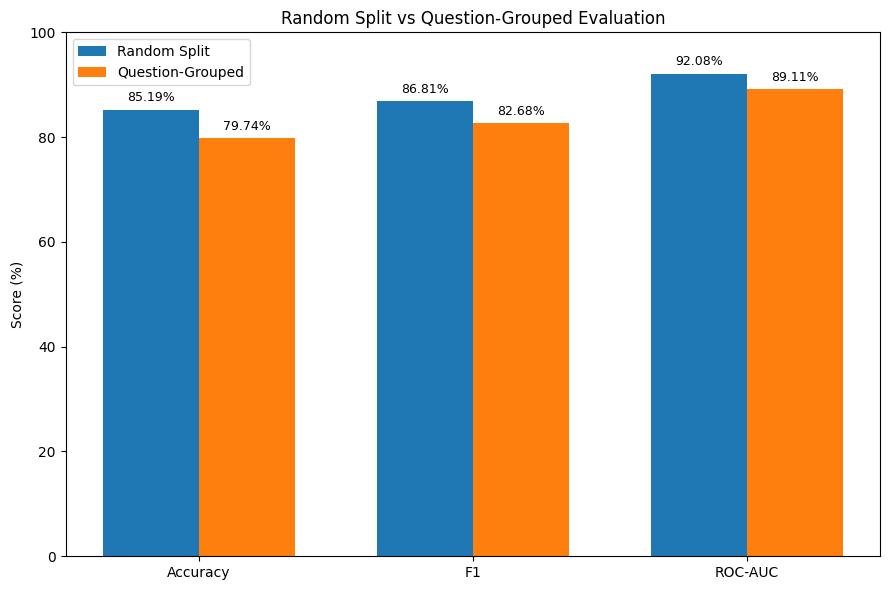

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Final Random Forest results
random_split = {
    "Accuracy": 85.19,
    "F1": 86.81,
    "ROC-AUC": 92.08
}

question_grouped = {
    "Accuracy": 79.74,
    "F1": 82.68,
    "ROC-AUC": 89.11
}

metrics = list(random_split.keys())
random_values = [random_split[m] for m in metrics]
grouped_values = [question_grouped[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(
    x - width/2,
    random_values,
    width,
    label="Random Split"
)

bars2 = ax.bar(
    x + width/2,
    grouped_values,
    width,
    label="Question-Grouped"
)

ax.set_ylabel("Score (%)")
ax.set_title(
    "Random Split vs Question-Grouped Evaluation"
)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 100)
ax.legend()

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [35]:
FIGURE_DIR = "/content/drive/MyDrive/factcheckAI/outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

fig.savefig(
    f"{FIGURE_DIR}/figure2_random_vs_question_grouped.png",
    dpi=300,
    bbox_inches="tight"
)

print(
    f"Saved to: {FIGURE_DIR}/figure2_random_vs_question_grouped.png"
)

Saved to: /content/drive/MyDrive/factcheckAI/outputs/figures/figure2_random_vs_question_grouped.png


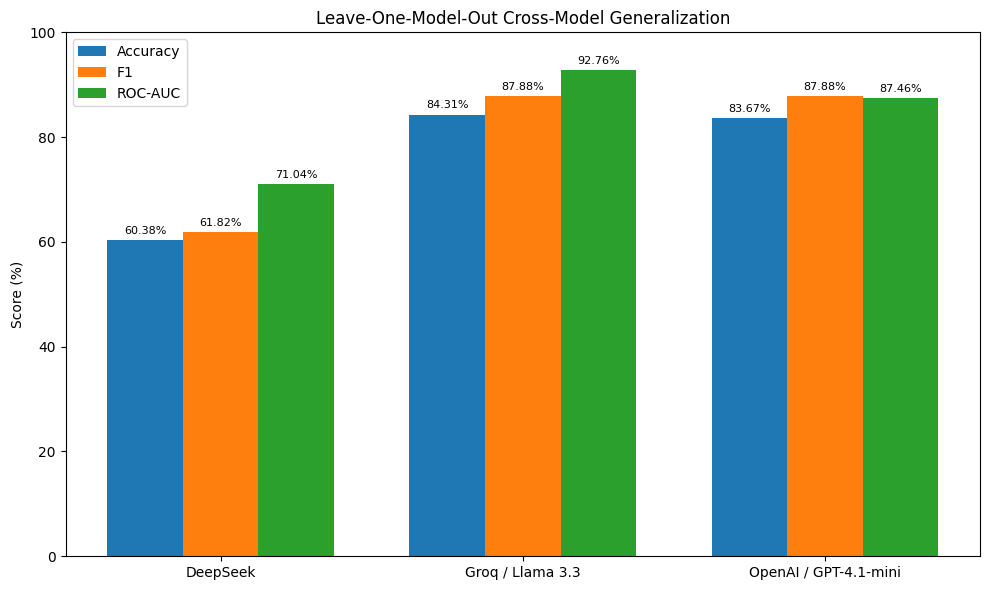

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Final question-grouped LOMO Random Forest results
held_out_models = [
    "DeepSeek",
    "Groq / Llama 3.3",
    "OpenAI / GPT-4.1-mini"
]

accuracy = [60.38, 84.31, 83.67]
f1 = [61.82, 87.88, 87.88]
roc_auc = [71.04, 92.76, 87.46]

x = np.arange(len(held_out_models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width,
    accuracy,
    width,
    label="Accuracy"
)

bars2 = ax.bar(
    x,
    f1,
    width,
    label="F1"
)

bars3 = ax.bar(
    x + width,
    roc_auc,
    width,
    label="ROC-AUC"
)

ax.set_ylabel("Score (%)")
ax.set_title("Leave-One-Model-Out Cross-Model Generalization")
ax.set_xticks(x)
ax.set_xticklabels(held_out_models)
ax.set_ylim(0, 100)
ax.legend()

# Add values above bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [37]:
FIGURE_DIR = "/content/drive/MyDrive/factcheckAI/outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

fig.savefig(
    f"{FIGURE_DIR}/figure3_lomo_cross_model.png",
    dpi=300,
    bbox_inches="tight"
)

print(
    f"Saved to: {FIGURE_DIR}/figure3_lomo_cross_model.png"
)

Saved to: /content/drive/MyDrive/factcheckAI/outputs/figures/figure3_lomo_cross_model.png


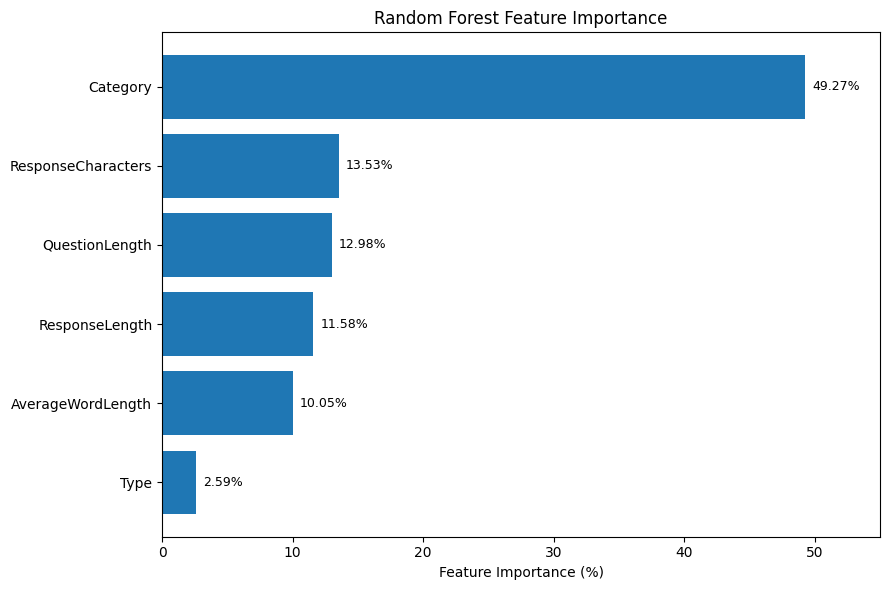

In [38]:
import matplotlib.pyplot as plt

# Verified Random Forest feature importance
features = [
    "Category",
    "ResponseCharacters",
    "QuestionLength",
    "ResponseLength",
    "AverageWordLength",
    "Type"
]

importance = [
    49.274134,
    13.531991,
    12.978368,
    11.582758,
    10.045248,
    2.587501
]

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(features[::-1], importance[::-1])

ax.set_xlabel("Feature Importance (%)")
ax.set_title("Random Forest Feature Importance")

# Add values
for i, value in enumerate(importance[::-1]):
    ax.annotate(
        f"{value:.2f}%",
        xy=(value, i),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 55)

plt.tight_layout()
plt.show()

In [39]:
FIGURE_DIR = "/content/drive/MyDrive/factcheckAI/outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

fig.savefig(
    f"{FIGURE_DIR}/figure4_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

print(
    f"Saved to: {FIGURE_DIR}/figure4_feature_importance.png"
)

Saved to: /content/drive/MyDrive/factcheckAI/outputs/figures/figure4_feature_importance.png


In [40]:
from sklearn.metrics import confusion_matrix

# Final question-grouped Random Forest
final_rf = Pipeline([
    ("preprocessor", scaled_preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

final_rf.fit(X_train, y_train)

y_pred = final_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[48 19]
 [12 74]]


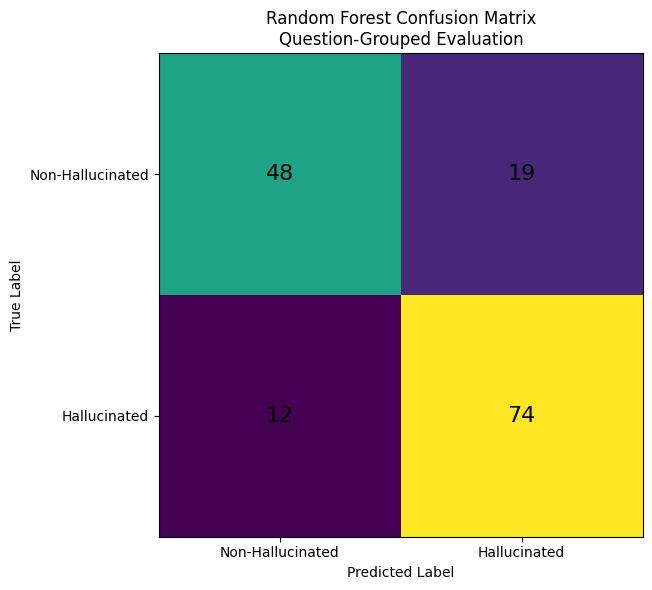

In [43]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Non-Hallucinated",
    "Hallucinated"
])

ax.set_yticklabels([
    "Non-Hallucinated",
    "Hallucinated"
])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_title(
    "Random Forest Confusion Matrix\n"
    "Question-Grouped Evaluation"
)

# Add cell values
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.tight_layout()
plt.show()

In [44]:
FIGURE_DIR = "/content/drive/MyDrive/factcheckAI/outputs/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

fig.savefig(
    f"{FIGURE_DIR}/figure5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

print(
    f"Saved to: {FIGURE_DIR}/figure5_confusion_matrix.png"
)

Saved to: /content/drive/MyDrive/factcheckAI/outputs/figures/figure5_confusion_matrix.png


In [45]:
# ============================================
# FINAL MASTER RESULTS TABLE
# ============================================

master_results = pd.DataFrame([
    {
        "Evaluation": "Random Split",
        "Experiment": "Random Forest",
        "Accuracy": 85.19,
        "Precision": 84.04,
        "Recall": 89.77,
        "F1": 86.81,
        "ROC-AUC": 92.08
    },
    {
        "Evaluation": "Question-Grouped",
        "Experiment": "Logistic Regression",
        "Accuracy": 79.09,
        "Precision": 80.00,
        "Recall": 83.72,
        "F1": 81.82,
        "ROC-AUC": 87.42
    },
    {
        "Evaluation": "Question-Grouped",
        "Experiment": "Decision Tree",
        "Accuracy": 75.82,
        "Precision": 76.34,
        "Recall": 82.56,
        "F1": 79.33,
        "ROC-AUC": 74.86
    },
    {
        "Evaluation": "Question-Grouped",
        "Experiment": "Random Forest",
        "Accuracy": 79.74,
        "Precision": 79.57,
        "Recall": 86.05,
        "F1": 82.68,
        "ROC-AUC": 89.11
    }
])

print(master_results.to_string(index=False))

      Evaluation          Experiment  Accuracy  Precision  Recall    F1  ROC-AUC
    Random Split       Random Forest     85.19      84.04   89.77 86.81    92.08
Question-Grouped Logistic Regression     79.09      80.00   83.72 81.82    87.42
Question-Grouped       Decision Tree     75.82      76.34   82.56 79.33    74.86
Question-Grouped       Random Forest     79.74      79.57   86.05 82.68    89.11


In [46]:
lomo_master = pd.DataFrame([
    {
        "Train Models": "GPT-4.1-mini + Llama 3.3",
        "Held-out Model": "DeepSeek",
        "Train Rows": 436,
        "Test Rows": 53,
        "Train Questions": 274,
        "Test Questions": 53,
        "Question Overlap": 0,
        "Accuracy": 60.38,
        "Precision": 51.52,
        "Recall": 77.27,
        "F1": 61.82,
        "ROC-AUC": 71.04
    },
    {
        "Train Models": "GPT-4.1-mini + DeepSeek",
        "Held-out Model": "Llama 3.3",
        "Train Rows": 447,
        "Test Rows": 51,
        "Train Questions": 284,
        "Test Questions": 51,
        "Question Overlap": 0,
        "Accuracy": 84.31,
        "Precision": 87.88,
        "Recall": 87.88,
        "F1": 87.88,
        "ROC-AUC": 92.76
    },
    {
        "Train Models": "Llama 3.3 + DeepSeek",
        "Held-out Model": "GPT-4.1-mini",
        "Train Rows": 423,
        "Test Rows": 49,
        "Train Questions": 279,
        "Test Questions": 49,
        "Question Overlap": 0,
        "Accuracy": 83.67,
        "Precision": 82.86,
        "Recall": 93.55,
        "F1": 87.88,
        "ROC-AUC": 87.46
    }
])

print(lomo_master.to_string(index=False))

            Train Models Held-out Model  Train Rows  Test Rows  Train Questions  Test Questions  Question Overlap  Accuracy  Precision  Recall    F1  ROC-AUC
GPT-4.1-mini + Llama 3.3       DeepSeek         436         53              274              53                 0     60.38      51.52   77.27 61.82    71.04
 GPT-4.1-mini + DeepSeek      Llama 3.3         447         51              284              51                 0     84.31      87.88   87.88 87.88    92.76
    Llama 3.3 + DeepSeek   GPT-4.1-mini         423         49              279              49                 0     83.67      82.86   93.55 87.88    87.46


In [47]:
final_ablation = ablation_df.copy()

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]:
    final_ablation[col] = (
        final_ablation[col] * 100
    ).round(2)

print(final_ablation.to_string(index=False))

  Feature Set                                                                              Features  Accuracy  Precision  Recall    F1  ROC-AUC
         Full Category, Type, ResponseLength, QuestionLength, ResponseCharacters, AverageWordLength     79.74      79.57   86.05 82.68    89.11
Question-only                                                        Category, Type, QuestionLength     75.82      78.16   79.07 78.61    83.86
Response-only                                 ResponseLength, ResponseCharacters, AverageWordLength     50.33      55.95   54.65 55.29    53.48
